# TinyChirp LEAF-Time TensorFlow

In [8]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
from typing import TYPE_CHECKING


from building_tensorflow.utils import (
    SAMPLE_RATE,
    FRAME_LENGTH,
    FRAME_STEP,
    TARGET_FRAMES_TIME,
    TARGET_AUDIO_LEN_TIME,
    DATASET_ROOT,
    get_paths,
    configure_tf_runtime,
    set_global_seed,
    make_time_datasets,
    evaluate_binary_classifier,
    build_representative_batches,
    export_keras_model_to_int8_tflite,
    collect_test_clips_for_rs,
    write_audio_sample_rs,
)

if TYPE_CHECKING:
    import keras
else:
    from tensorflow import keras

configure_tf_runtime()
set_global_seed()

paths = get_paths("leaf_time_tf")
OUT_TFLITE = paths.out_tflite
OUT_AUDIO_RS = paths.out_audio_rs

print("Dataset root:", DATASET_ROOT)
print("Model output:", OUT_TFLITE)
print("Audio sample output:", OUT_AUDIO_RS)
print("Sample rate:", SAMPLE_RATE)
print("Frame length:", FRAME_LENGTH)
print("Frame step:", FRAME_STEP)
print("Target frames (time):", TARGET_FRAMES_TIME)
print("Target audio length (time):", TARGET_AUDIO_LEN_TIME)


Dataset root: /home/nathan/Documents/tiny-chirp-microflow/dataset
Model output: /home/nathan/Documents/tiny-chirp-microflow/models/leaf_time_tf.tflite
Audio sample output: /home/nathan/Documents/tiny-chirp-microflow/src/audio_sample.rs
Sample rate: 16000
Frame length: 1024
Frame step: 256
Target frames (time): 184
Target audio length (time): 47872


In [10]:
train_ds, val_ds, test_ds, label_names = make_time_datasets()
num_labels = len(label_names)
print("Classes:", label_names)
print("Num labels:", num_labels)


Found 11292 files belonging to 2 classes.
Found 1380 files belonging to 2 classes.
Found 1393 files belonging to 2 classes.
Classes: ['non_target' 'target']
Num labels: 2


In [11]:
import math
import numpy as np
import tensorflow as tf
import keras

class GaborConv1D(keras.layers.Layer):
    def __init__(self, num_filters, kernel_size, **kwargs):
        super().__init__(**kwargs)
        self.num_filters = num_filters
        self.kernel_size = kernel_size
        
        # We initialize frequencies more uniformly to ensure it catches high-pitch birds
        self.center_freqs = self.add_weight(shape=(1, 1, num_filters), initializer="random_uniform")
        self.bandwidths = self.add_weight(shape=(1, 1, num_filters), initializer="ones")

    def get_filters(self):
        limit = (self.kernel_size - 1) / 2.0
        t = tf.cast(tf.linspace(-limit, limit, self.kernel_size), tf.float32)
        t = tf.reshape(t, [-1, 1, 1]) 
        env = tf.exp(-0.5 * tf.square(t * self.bandwidths))
        cos_mod = tf.cos(2.0 * math.pi * self.center_freqs * t)
        sin_mod = tf.sin(2.0 * math.pi * self.center_freqs * t)
        return tf.concat([env * cos_mod, env * sin_mod], axis=-1)

    def call(self, inputs):
        conv = tf.nn.conv1d(inputs, self.get_filters(), stride=1, padding='SAME')
        real, imag = tf.split(conv, 2, axis=-1)
        return tf.square(real) + tf.square(imag)


class GaussianPool1D(keras.layers.Layer):
    def __init__(self, num_filters, pool_size, stride, **kwargs):
        super().__init__(**kwargs)
        self.num_filters = num_filters
        self.pool_size = pool_size
        self.stride = stride
        self.bandwidths = self.add_weight(shape=(1, num_filters, 1), initializer=tf.constant_initializer(0.4))

    def get_filters(self):
        limit = (self.pool_size - 1) / 2.0
        t = tf.cast(tf.linspace(-limit, limit, self.pool_size), tf.float32)
        t = tf.reshape(t, [-1, 1, 1]) 
        gauss = tf.exp(-0.5 * tf.square(t * self.bandwidths))
        return gauss / tf.reduce_sum(gauss, axis=0, keepdims=True)

    def call(self, inputs):
        return tf.nn.depthwise_conv2d(
            tf.expand_dims(inputs, axis=1), 
            tf.expand_dims(self.get_filters(), axis=0), 
            strides=[1, 1, self.stride, 1], 
            padding='SAME'
        )[:, 0, :, :]


class LogCompression(keras.layers.Layer):
    """Instantly compresses audio without heavy loops. Perfect for CPU."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = 1e-6

    def call(self, inputs):
        return tf.math.log(inputs + self.epsilon)

In [12]:
NUM_FILTERS = 32 
KERNEL_SIZE = 64
STRIDE = 64

def build_training_model(num_labels: int) -> keras.Model:
    inputs = keras.Input(shape=(TARGET_AUDIO_LEN_TIME, 1))

    x = GaborConv1D(num_filters=NUM_FILTERS, kernel_size=KERNEL_SIZE, name="gabor_conv")(inputs)
    x = GaussianPool1D(num_filters=NUM_FILTERS, pool_size=KERNEL_SIZE, stride=STRIDE, name="gauss_pool")(x)
    x = LogCompression(name="log_compress")(x) # Fast replacement for sPCEN
    
    x = keras.layers.Conv1D(filters=16, kernel_size=3, activation='relu', padding='same')(x)
    x = keras.layers.MaxPooling1D(pool_size=2)(x)
    x = keras.layers.Dropout(0.25)(x) # Added dropout similar to your baseline
    
    x = keras.layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(x)
    x = keras.layers.MaxPooling1D(pool_size=2)(x)
    
    x = keras.layers.GlobalAveragePooling1D()(x)
    x = keras.layers.Dense(64, activation='relu')(x)
    outputs = keras.layers.Dense(num_labels, activation=None, name="dense_logits")(x)
    
    return keras.Model(inputs, outputs, name="leaf_fast_bird_model")


num_labels = 2 
training_model = build_training_model(num_labels)

# Use XLA compilation to speed up training
training_model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
    jit_compile=True  # This forces TF to optimize the custom math loops
)

In [13]:
training_model.summary()

Model: "leaf_fast_bird_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 47872, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gabor_conv (GaborConv1D)        │ (None, 47872, 32)      │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gauss_pool (GaussianPool1D)     │ (None, 748, 32)        │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_compress (LogCompression)   │ (None, 748, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 748, 16)        │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 374, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 374, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 374, 32)        │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 187, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_logits (Dense)            │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,458 (21.32 KB)

 Trainable params: 5,458 (21.32 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',        
    patience=3,               
    restore_best_weights=True
)

history = training_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    validation_steps=50,
    callbacks=[early_stopping] 
)

NameError: name 'training_model' is not defined

353it [01:40,  3.50it/s]2026-04-02 15:30:21.359684: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence

44it [00:12,  3.48it/s]2026-04-02 15:30:34.313771: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



=== Binary classifier metrics : TEST SET===
Threshold: 0.4421  (best F2 threshold)
Accuracy : 0.9706
Precision: 0.9264
Recall   : 0.9891
F2 score : 0.9759
=== Binary classifier metrics : TRAIN SET===
AUC      : 0.9973


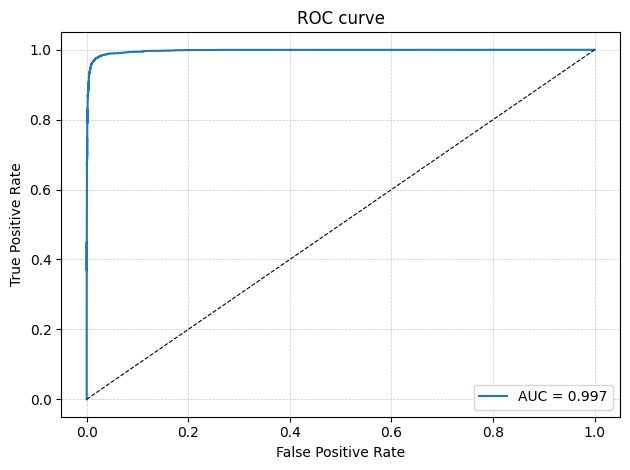

{'train': {'threshold': 0.5,
  'accuracy': 0.9772405242649663,
  'precision': 0.9541847965190683,
  'recall': 0.9795060430898581,
  'f2': 0.9743348491976375,
  'auc': 0.9973238010655449,
  'roc_fpr': array([0.        , 0.        , 0.        , ..., 0.99986642, 1.        ,
         1.        ]),
  'roc_tpr': array([0.        , 0.2228061 , 0.22254335, ..., 1.        , 1.        ,
         1.        ]),
  'roc_thresholds': array([          inf, 9.9719352e-01, 9.9719363e-01, ..., 1.2190730e-28,
         1.8251675e-33,          -inf], dtype=float32)},
 'test': {'threshold': 0.44206440448760986,
  'accuracy': 0.9705671213208902,
  'precision': 0.9263803680981595,
  'recall': 0.9890829694323144,
  'f2': 0.975872468763464,
  'auc': None,
  'roc_fpr': None,
  'roc_tpr': None,
  'roc_thresholds': None}}

In [17]:
evaluate_binary_classifier(training_model, train_ds, test_ds, threshold=0.5)


In [15]:

class SquaredModulus(keras.layers.Layer):
    def call(self, inputs):
        real, imag = tf.split(inputs, 2, axis=-1)
        return tf.square(real) + tf.square(imag)

gabor_layer = training_model.get_layer("gabor_conv")
pool_layer = training_model.get_layer("gauss_pool")

baked_gabor = gabor_layer.get_filters().numpy()  
baked_gauss = pool_layer.get_filters().numpy()  

infer_inputs = keras.Input(shape=(TARGET_AUDIO_LEN_TIME, 1))

x = keras.layers.Conv1D(
    filters=NUM_FILTERS * 2, 
    kernel_size=KERNEL_SIZE, 
    padding="same", 
    use_bias=False, 
    name="baked_gabor_conv"
)(infer_inputs)
x = SquaredModulus(name="squared_modulus")(x)
x = keras.layers.DepthwiseConv1D(
    kernel_size=KERNEL_SIZE, 
    strides=STRIDE, 
    padding="same", 
    use_bias=False, 
    name="baked_gauss_dw"
)(x)
x = LogCompression(name="log_compress")(x)

for layer in training_model.layers[4:]:
    x = layer(x)

inference_model = keras.Model(infer_inputs, x, name="leaf_fast_bird_inference")

inference_model.get_layer("baked_gabor_conv").set_weights([baked_gabor])
inference_model.get_layer("baked_gauss_dw").set_weights([baked_gauss])

for batch_audio, _ in test_ds.take(1):
    batch_audio_np = batch_audio.numpy()
    logits_train = training_model.predict(batch_audio_np, verbose=0)
    logits_infer = inference_model.predict(batch_audio_np, verbose=0)
    print(f"Max abs diff: {np.max(np.abs(logits_train - logits_infer)):.8f}")

Max abs diff: 0.00000381


2026-04-02 15:28:26.274607: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [16]:
rep_batches = build_representative_batches(test_ds, target_len=TARGET_AUDIO_LEN_TIME, take=100)
export_keras_model_to_int8_tflite(inference_model, rep_batches, OUT_TFLITE)
print(f"Success! Wrote {OUT_TFLITE}")

clips = collect_test_clips_for_rs(
    DATASET_ROOT / "testing",
    sample_rate=SAMPLE_RATE,
    target_len=TARGET_AUDIO_LEN_TIME,
    num_per_label=2,
)
write_audio_sample_rs(
    OUT_AUDIO_RS,
    clips,
    SAMPLE_RATE,
    generator_name="building_tensorflow/leaf_time.ipynb",
)
print("Wrote", OUT_AUDIO_RS, "clips=", len(clips), "samples_per_clip=", len(clips[0][1]))


2026-04-02 15:28:26.580240: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


INFO:tensorflow:Assets written to: temp_saved_model/assets


INFO:tensorflow:Assets written to: temp_saved_model/assets


Saved artifact at 'temp_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 47872, 1), dtype=tf.float32, name='keras_tensor_23')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  130165940518080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130165940517728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130168385454320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130168385454496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130168385456608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130168248351232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130168248351760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130168248350528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130168248350704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130168248350880: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1775136507.179299   25663 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1775136507.179440   25663 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.
2026-04-02 15:28:27.184174: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: temp_saved_model
2026-04-02 15:28:27.184745: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-02 15:28:27.184759: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: temp_saved_model
2026-04-02 15:28:27.192967: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled
2026-04-02 15:28:27.193697: I tensorflow/cc/saved_model/loader.cc:234] Restoring SavedModel bundle.
2026-04-02 15:28:27.223294: I tensorflow/cc/saved_model/loader.cc:218] Running initialization op on SavedModel bundle at path: temp_saved_model
2026-04-02 15:28:27.231174: I tensorflow/cc/saved_model/loader.cc

Success! Wrote /home/nathan/Documents/tiny-chirp-microflow/models/leaf_time_tf.tflite
Found 1393 files belonging to 2 classes.


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


Wrote /home/nathan/Documents/tiny-chirp-microflow/src/audio_sample.rs clips= 4 samples_per_clip= 47872
